# Laboratorium 3
## Analiza parametrów drzewa decyzyjnego

W tym laboratorium należy samodzielnie przeprowadzić analizę wpływu parametrów drzewa decyzyjnego na jakość klasyfikacji.

Należy wykorzystać wiedzę oraz kod z poprzednich zajęć.

## Przygotowanie danych

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_discretized.csv to data_discretized.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:

# Wczytaj dane już zdyskretyzowane
#wczuje dane po dyskretynizacji z pliku csv do dataframe
df_disc = pd.read_csv("data_discretized.csv")

print("Podgląd danych po dyskretyzacji:")
print(df_disc.head())

print("\nInformacje o danych:")
print(df_disc.info())

print("\nLiczba braków danych:")
print(df_disc.isnull().sum())

#tworze macierz cech x przez usuniecie kolumny docelowej uns
X = df_disc.drop("UNS", axis=1)

#tworze obiekt kodera etykiet
le = LabelEncoder()
#zamieniam etykiety tekstowe z kolumnu uns na liczby całkowite
y = le.fit_transform(df_disc["UNS"])
# Przygotuj dane (X, y), podział na zbiór treningowy i testowy
# PODZIAŁ DANYCH
# Używamy stratyfikacji, aby zachować proporcje klas
# w zbiorze treningowym i testowym.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)
print("Klasy:", list(le.classes_))

Podgląd danych po dyskretyzacji:
   STG  SCG  STR  LPR  PEG       UNS
0  0.0  0.0  0.0  0.0  0.0  Very Low
1  0.0  0.0  0.0  0.0  3.0      High
2  0.0  0.0  0.0  1.0  1.0       Low
3  0.0  0.0  0.0  3.0  1.0    Middle
4  0.0  0.0  0.0  3.0  0.0       Low

Informacje o danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STG     403 non-null    float64
 1   SCG     403 non-null    float64
 2   STR     403 non-null    float64
 3   LPR     403 non-null    float64
 4   PEG     403 non-null    float64
 5   UNS     403 non-null    object 
dtypes: float64(5), object(1)
memory usage: 19.0+ KB
None

Liczba braków danych:
STG    0
SCG    0
STR    0
LPR    0
PEG    0
UNS    0
dtype: int64
Rozmiar zbioru treningowego: (302, 5)
Rozmiar zbioru testowego: (101, 5)
Klasy: ['High', 'Low', 'Middle', 'Very Low']


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Zadanie 1

1. Przeprowadź klasyfikację danych dla drzewa decyzyjnego o różnej głębokości.  
2. Dokonaj analizy jakości klasyfikacji uzyskanych wyników.  
3. Wskaż, przy jakiej głębokości drzewo uzyskuje najlepszą jakość klasyfikacji.

Wyniki dla różnych wartości max_depth:
    max_depth  train_accuracy  cv_mean_accuracy    cv_std
0           1        0.569536          0.559672  0.014539
1           2        0.738411          0.721913  0.045758
2           3        0.827815          0.804973  0.056502
3           4        0.847682          0.811421  0.052613
4           5        0.864238          0.811257  0.054140
5           6        0.897351          0.768470  0.054450
6           7        0.920530          0.758415  0.044565
7           8        0.937086          0.755027  0.047152
8           9        0.956954          0.761585  0.050972
9          10        0.963576          0.755027  0.047152
10         11        0.970199          0.755027  0.051510
11         12        0.970199          0.748470  0.049066
12         13        0.970199          0.748470  0.049066
13         14        0.970199          0.748470  0.049066
14         15        0.970199          0.748470  0.049066

Najlepsza wartość max_depth (wg 

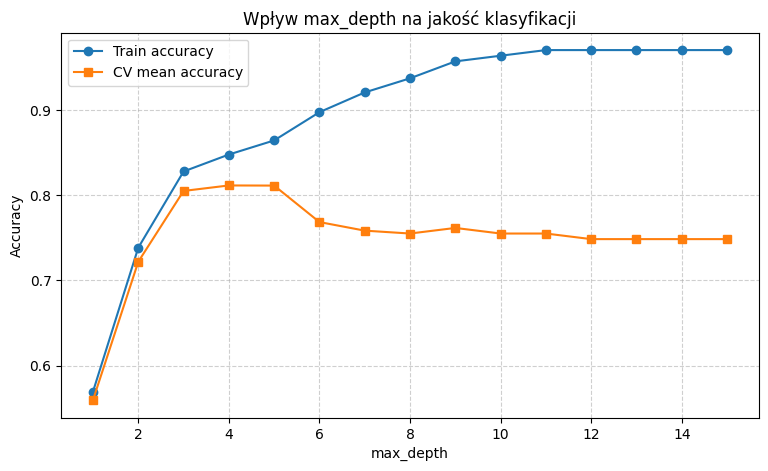


Raport klasyfikacji dla najlepszego modelu z Zadania 1:
              precision    recall  f1-score   support

        High       0.90      1.00      0.95        26
         Low       0.74      0.91      0.82        32
      Middle       1.00      0.77      0.87        31
    Very Low       0.67      0.50      0.57        12

    accuracy                           0.84       101
   macro avg       0.83      0.80      0.80       101
weighted avg       0.85      0.84      0.84       101

Accuracy na zbiorze testowym: 0.8416

Wniosek: najlepszy model wg walidacji krzyżowej uzyskano dla max_depth = 4.


In [ ]:
# Twoje rozwiązanie
#1. Klasyfikacja danych dla drzewa decyzyjnego o różnej głębokości - analiza wpływu max_depth
#2.AnalizA jakości klasyfikacji uzyskanych wyników
#3. Jaka głębokość zapewnia najlepszą jakość klasyfikacji ?
# tworzę zakres badanych wartości max_depth od 1 do 15
depth_values = range(1, 16)
# tworzę pustą listę, do której będę zapisywać wyniki dla każdej głębokości drzewa
results_depth = []
# przechodzę pętlą po wszystkich wartościach max_depth
for depth in depth_values:
    clf = DecisionTreeClassifier(
        max_depth=depth,
        criterion="entropy",
        random_state=42
    )

    # trening modelu
    clf.fit(X_train, y_train)

    # ocena na treningu
    y_train_pred = clf.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # walidacja krzyżowa na treningu
    cv_scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results_depth.append({
        # aktualna wartość głębokości
        "max_depth": depth,
        # accuracy na treningu
        "train_accuracy": train_acc,
        # średni wynik z CV
        "cv_mean_accuracy": cv_scores.mean(),
        # odchylenie standardowe wyników CV
        "cv_std": cv_scores.std()
    })
# zamieniam listę słowników na tabelę DataFrame
results_depth_df = pd.DataFrame(results_depth)


print("Wyniki dla różnych wartości max_depth:")
print(results_depth_df)
# wybieram wiersz z najwyższą średnią accuracy z walidacji krzyżowej
best_depth_row = results_depth_df.loc[results_depth_df["cv_mean_accuracy"].idxmax()]

# z wybranego wiersza pobieram najlepszą wartość max_depth
best_depth = int(best_depth_row["max_depth"])

print("\nNajlepsza wartość max_depth (wg walidacji krzyżowej):", best_depth)
print("Najlepszy średni wynik CV:", round(best_depth_row["cv_mean_accuracy"], 4))

# wykres
plt.figure(figsize=(9, 5))
plt.plot(results_depth_df["max_depth"], results_depth_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(results_depth_df["max_depth"], results_depth_df["cv_mean_accuracy"], marker="s", label="CV mean accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Wpływ max_depth na jakość klasyfikacji")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# końcowa ocena najlepszego modelu na testowym
best_depth_clf = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion="entropy",
    random_state=42
)

best_depth_clf.fit(X_train, y_train)
y_pred_best_depth = best_depth_clf.predict(X_test)

test_acc_best_depth = accuracy_score(y_test, y_pred_best_depth)

print("\nRaport klasyfikacji dla najlepszego modelu z Zadania 1:")
print(classification_report(y_test, y_pred_best_depth, target_names=le.classes_))
print("Accuracy na zbiorze testowym:", round(test_acc_best_depth, 4))

print(f"\nWniosek: najlepszy model wg walidacji krzyżowej uzyskano dla max_depth = {best_depth}.")




W Zadaniu 1 przeanalizowano wpływ parametru max_depth na jakość klasyfikacji. Dla kolejnych głębokości drzewa obliczono dokładność na zbiorze treningowym oraz średnią dokładność uzyskaną w 5-krotnej walidacji krzyżowej. Na tej podstawie wybrano najlepszą wartość parametru.

Z przeprowadzonych obliczeń wynika, że najlepszy wynik walidacyjny uzyskano dla max_depth = 4. Oznacza to, że drzewo o tej głębokości najlepiej uogólniało dane treningowe. Dla większych głębokości accuracy na treningu rosło, ale średnia accuracy z walidacji krzyżowej nie poprawiała się, co może świadczyć o przeuczeniu modelu.

Końcowy model z parametrem max_depth = 4 został oceniony na zbiorze testowym i osiągnął accuracy równą około 0.8416

# Zadanie 2

1. Przeprowadź klasyfikację danych dla drzewa decyzyjnego dla różnych wartości minimalnej liczby obiektów w liściach drzewa.  
2. Dokonaj analizy jakości klasyfikacji uzyskanych wyników.  
3. Wskaż, przy jakiej liczbie obiektów w liściu drzewo uzyskuje najlepszą jakość klasyfikacji.

Wyniki dla różnych wartości min_samples_leaf:
    min_samples_leaf  train_accuracy  cv_mean_accuracy    cv_std
0                  1        0.970199          0.748470  0.049066
1                  2        0.907285          0.798197  0.044188
2                  3        0.890728          0.804536  0.049652
3                  4        0.874172          0.788142  0.027981
4                  5        0.867550          0.761858  0.059327
5                  6        0.867550          0.778415  0.049607
6                  7        0.854305          0.788251  0.037443
7                  8        0.854305          0.781694  0.044965
8                  9        0.844371          0.794973  0.045003
9                 10        0.844371          0.798306  0.048223
10                11        0.844371          0.798415  0.053141
11                12        0.844371          0.798415  0.060014
12                13        0.837748          0.795082  0.061210
13                14        0.827815        

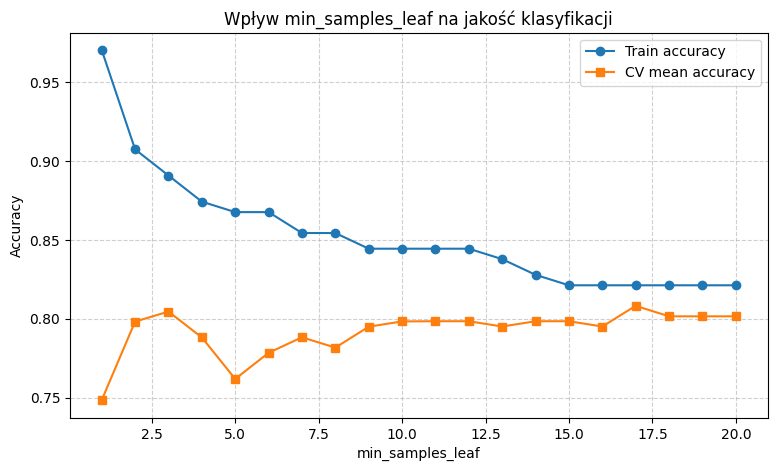


Raport klasyfikacji dla najlepszego modelu z Zadania 2:
              precision    recall  f1-score   support

        High       0.88      0.85      0.86        26
         Low       0.81      0.91      0.85        32
      Middle       0.87      0.87      0.87        31
    Very Low       0.67      0.50      0.57        12

    accuracy                           0.83       101
   macro avg       0.81      0.78      0.79       101
weighted avg       0.83      0.83      0.83       101

Accuracy na zbiorze testowym: 0.8317

Wniosek: najlepszy model wg walidacji krzyżowej uzyskano dla min_samples_leaf = 17.


In [ ]:
# Twoje rozwiązanie
#1. Klasyfikacja - różne wartości min. l. obiektów w liściach drzewa - analizu wplywu min_samples_leaf
#2. Analiza jakości klasyfikacji wyników
#3. Jaka liczba obiektów w liściu dzrewo uzyskuje najlepszą jakość klasyfikacji?

leaf_values = range(1, 21)
results_leaf = []

for leaf in leaf_values:
    clf = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        criterion="entropy",
        random_state=42
    )

    # trening modelu
    clf.fit(X_train, y_train)

    # ocena na treningu
    y_train_pred = clf.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # walidacja krzyżowa
    cv_scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    results_leaf.append({
        "min_samples_leaf": leaf,
        "train_accuracy": train_acc,
        "cv_mean_accuracy": cv_scores.mean(),
        "cv_std": cv_scores.std()
    })

results_leaf_df = pd.DataFrame(results_leaf)


print("Wyniki dla różnych wartości min_samples_leaf:")
print(results_leaf_df)

best_leaf_row = results_leaf_df.loc[results_leaf_df["cv_mean_accuracy"].idxmax()]
best_leaf = int(best_leaf_row["min_samples_leaf"])

print("\nNajlepsza wartość min_samples_leaf (wg walidacji krzyżowej):", best_leaf)
print("Najlepszy średni wynik CV:", round(best_leaf_row["cv_mean_accuracy"], 4))

# wykres
plt.figure(figsize=(9, 5))
plt.plot(results_leaf_df["min_samples_leaf"], results_leaf_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(results_leaf_df["min_samples_leaf"], results_leaf_df["cv_mean_accuracy"], marker="s", label="CV mean accuracy")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Wpływ min_samples_leaf na jakość klasyfikacji")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# końcowa ocena najlepszego modelu na testowym
best_leaf_clf = DecisionTreeClassifier(
    min_samples_leaf=best_leaf,
    criterion="entropy",
    random_state=42
)

best_leaf_clf.fit(X_train, y_train)
y_pred_best_leaf = best_leaf_clf.predict(X_test)

test_acc_best_leaf = accuracy_score(y_test, y_pred_best_leaf)

print("\nRaport klasyfikacji dla najlepszego modelu z Zadania 2:")
print(classification_report(y_test, y_pred_best_leaf, target_names=le.classes_))
print("Accuracy na zbiorze testowym:", round(test_acc_best_leaf, 4))

print(f"\nWniosek: najlepszy model wg walidacji krzyżowej uzyskano dla min_samples_leaf = {best_leaf}.")



W Zadaniu 2 przeanalizowano wpływ parametru min_samples_leaf na jakość klasyfikacji. Dla każdej wartości tego parametru wyznaczono dokładność na zbiorze treningowym oraz średnią dokładność uzyskaną w walidacji krzyżowej.

Na podstawie otrzymanych wyników stwierdzono, że najlepszą średnią accuracy w walidacji krzyżowej uzyskano dla min_samples_leaf = 17. Oznacza to, że model z większą minimalną liczbą obiektów w liściu był bardziej stabilny i mniej podatny na przeuczenie.

Końcowy model z tym parametrem został oceniony na zbiorze testowym i osiągnął accuracy równą około 0.8317.

# Zadanie 3 ⭐

1. Jakie połączenie parametrów wskazanych w zadaniu 1 i zadaniu 2 pozwala na uzyskanie najlepszej jakości klasyfikacji?

Najlepsze parametry: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2}
Najlepszy średni wynik CV: 0.8212

Raport klasyfikacji dla najlepszego modelu z Zadania 3:
              precision    recall  f1-score   support

        High       0.89      0.96      0.93        26
         Low       0.76      1.00      0.86        32
      Middle       0.96      0.77      0.86        31
    Very Low       1.00      0.50      0.67        12

    accuracy                           0.86       101
   macro avg       0.90      0.81      0.83       101
weighted avg       0.88      0.86      0.85       101

Accuracy na zbiorze testowym: 0.8614

Najlepsze kombinacje parametrów:
    param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  \
41                5                       2         0.821202        0.048367   
30                4                       1         0.811421        0.052613   
31                4                       2         0.811421        0.052613  

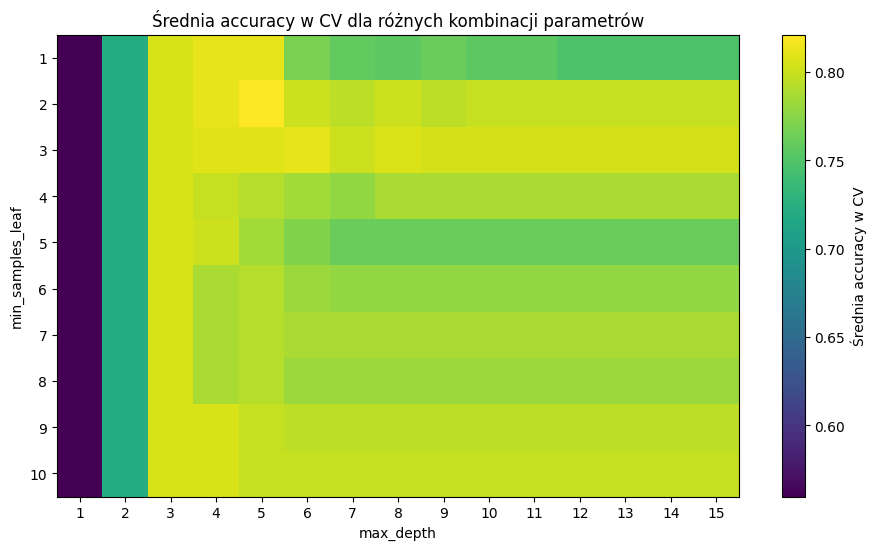


Wniosek: najlepszy model wg walidacji krzyżowej uzyskano dla max_depth = 5 oraz min_samples_leaf = 2.


In [ ]:
# Twoje rozwiązanie
#Najlepsza jakośc klasyfikacji - parametry
#NAJLEPSZE POŁĄCZENIE max_depth i min_samples_leaf

param_grid = {
    "max_depth": range(1, 16),
    "min_samples_leaf": range(1, 11),
    "criterion": ["entropy"]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)


print("Najlepsze parametry:", grid.best_params_)
print("Najlepszy średni wynik CV:", round(grid.best_score_, 4))

best_model = grid.best_estimator_
y_pred_best_combo = best_model.predict(X_test)
test_acc_best_combo = accuracy_score(y_test, y_pred_best_combo)

print("\nRaport klasyfikacji dla najlepszego modelu z Zadania 3:")
print(classification_report(y_test, y_pred_best_combo, target_names=le.classes_))
print("Accuracy na zbiorze testowym:", round(test_acc_best_combo, 4))

# tabela wyników
results_combo_df = pd.DataFrame(grid.cv_results_)

summary_combo = results_combo_df[[
    "param_max_depth",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score"
]].sort_values(by=["rank_test_score", "mean_test_score"], ascending=[True, False])

print("\nNajlepsze kombinacje parametrów:")
print(summary_combo.head(10))

# heatmapa
pivot_table = results_combo_df.pivot_table(
    index="param_min_samples_leaf",
    columns="param_max_depth",
    values="mean_test_score"
)

plt.figure(figsize=(11, 6))
plt.imshow(pivot_table, aspect="auto")
plt.colorbar(label="Średnia accuracy w CV")
plt.xticks(
    ticks=np.arange(len(pivot_table.columns)),
    labels=pivot_table.columns
)
plt.yticks(
    ticks=np.arange(len(pivot_table.index)),
    labels=pivot_table.index
)
plt.xlabel("max_depth")
plt.ylabel("min_samples_leaf")
plt.title("Średnia accuracy w CV dla różnych kombinacji parametrów")
plt.show()

best_params = grid.best_params_
print(
    f"\nWniosek: najlepszy model wg walidacji krzyżowej uzyskano dla "
    f"max_depth = {best_params['max_depth']} oraz "
    f"min_samples_leaf = {best_params['min_samples_leaf']}."
)


W Zadaniu 3 przeprowadzono jednoczesną analizę parametrów max_depth oraz min_samples_leaf z wykorzystaniem metody GridSearchCV. Sprawdzono wiele kombinacji wartości obu parametrów, a następnie dla każdej z nich obliczono średnią accuracy w walidacji krzyżowej.

Najlepszy wynik uzyskano dla kombinacji:

max_depth = 5

min_samples_leaf = 2

Oznacza to, że właśnie taka konfiguracja drzewa najlepiej równoważy zdolność dopasowania modelu do danych oraz jego zdolność uogólniania. Końcowy model wybrany przez GridSearchCV osiągnął accuracy na zbiorze testowym równą około 0.8614, co było najlepszym wynikiem spośród analizowanych wariantów.

Dodatkowo wykonano tabelę najlepszych kombinacji parametrów oraz heatmapę, która pozwala wizualnie porównać jakość klasyfikacji dla różnych ustawień modelu.

#Podsumowanie końcowe

In [ ]:
summary_df = pd.DataFrame({
    "Zadanie": [
        "Zadanie 1 - max_depth",
        "Zadanie 2 - min_samples_leaf",
        "Zadanie 3 - max_depth + min_samples_leaf"
    ],
    "Najlepszy parametr / parametry": [
        f"max_depth = {best_depth}",
        f"min_samples_leaf = {best_leaf}",
        f"max_depth = {best_params['max_depth']}, min_samples_leaf = {best_params['min_samples_leaf']}"
    ],
    "Kryterium wyboru": [
        "najwyższa średnia accuracy w CV",
        "najwyższa średnia accuracy w CV",
        "najwyższa średnia accuracy w GridSearchCV"
    ],
    "Accuracy na zbiorze testowym": [
        round(test_acc_best_depth, 4),
        round(test_acc_best_leaf, 4),
        round(test_acc_best_combo, 4)
    ]
})

print("\n PODSUMOWANIE ")
print(summary_df)


 PODSUMOWANIE 
                                    Zadanie  \
0                     Zadanie 1 - max_depth   
1              Zadanie 2 - min_samples_leaf   
2  Zadanie 3 - max_depth + min_samples_leaf   

        Najlepszy parametr / parametry  \
0                        max_depth = 4   
1                min_samples_leaf = 17   
2  max_depth = 5, min_samples_leaf = 2   

                            Kryterium wyboru  Accuracy na zbiorze testowym  
0            najwyższa średnia accuracy w CV                        0.8416  
1            najwyższa średnia accuracy w CV                        0.8317  
2  najwyższa średnia accuracy w GridSearchCV                        0.8614  


Na podstawie przeprowadzonych eksperymentów stwierdzono, że najlepsze wyniki uzyskano w Zadaniu 3, gdzie jednocześnie dostrajano parametry max_depth oraz min_samples_leaf. Model wybrany przez GridSearchCV osiągnął najwyższą dokładność na zbiorze testowym spośród wszystkich analizowanych wariantów.

W Zadaniu 1 najlepsza wartość parametru max_depth wyniosła 4, natomiast w Zadaniu 2 najlepsza wartość min_samples_leaf wyniosła 17. Jednak najlepszy wynik końcowy uzyskano dopiero po jednoczesnym strojeniu obu parametrów, co potwierdza, że analiza wielu hiperparametrów jednocześnie może poprawić skuteczność modelu.